In [ ]:
%pip install puremacro


# Continuous State-Space Dynamic Programming: Chebyshev Collocation and Finite Element Galerkin Projection

**How do quantitative macroeconomists solve dynamic general equilibrium models without the curse of dimensionality and discretization distortion of grid-based value function iteration, and when should one deploy global orthogonal Chebyshev polynomials versus localized finite element Galerkin projection?**

In modern macroeconomics, economic decision variables (capital, bonds, collateral constraints) live on continuous state manifolds. Traditional discrete-grid value function iteration forces asset choices onto an artificial discrete lattice, inducing $O(N_a)$ truncation error, non-differentiability, and combinatorial state-space explosion. Continuous projection methods approximate policy and value functions directly on the continuous domain: global orthogonal Chebyshev collocation delivers exponential "spectral" convergence ($O(c^{-N})$) for smooth, real-analytic manifolds, whereas localized Finite Element Methods (FEM) provide algebraic convergence ($O(h^2)$) while uniquely resolving sharp kinks, borrowing constraints, and occasionally binding financial frictions with zero Gibbs ringing.

## The method in math — Continuous State-Space Projection

**1. Chebyshev Orthogonal Polynomial Collocation.** Map state $k \in [a, b]$ to the canonical interval $x \in [-1, 1]$ via $x = \frac{2k - (a + b)}{b - a}$. The Chebyshev polynomials of the first kind satisfy the 3-term recurrence relation:
$$ T_0(x) = 1, \qquad T_1(x) = x, \qquad T_{n+1}(x) = 2x T_n(x) - T_{n-1}(x). $$
Evaluating at the $N+1$ Chebyshev-Gauss-Lobatto extrema nodes $x_i = -\cos\left(\frac{i \pi}{N}\right)$, the policy function $g_\theta(k) = \sum_{n=0}^N \theta_n T_n(x(k))$ satisfies the continuous Euler equation residual:
$$ \mathcal{R}_{\text{Euler}}(\theta; k_i) \equiv 1 - \beta \frac{u'\left(c(g_\theta(k_i), g_\theta(g_\theta(k_i)))\right)}{u'\left(c(k_i, g_\theta(k_i))\right)} f'\left(g_\theta(k_i)\right) = 0, \quad i = 0, \dots, N. $$
For continuous Bellman value collocation, value coefficients $c_v$ satisfy $\mathcal{R}_{\text{Bellman}}(c_v; k_i) \equiv V(k_i) - \max_{k'} \left[ u(k_i, k') + \beta \sum_{n=0}^N c_{v, n} T_n(x(k')) \right] = 0$.

**2. Finite Element Galerkin Projection.** Partition $[a, b]$ into $E$ elements with nodes $k_0 < k_1 < \dots < k_E$ and piecewise linear Lagrange hat basis functions $\phi_j(k)$ having compact support $[k_{j-1}, k_{j+1}]$:
$$ \phi_j(k) = \frac{k - k_{j-1}}{k_j - k_{j-1}} \mathbf{1}_{[k_{j-1}, k_j]}(k) + \frac{k_{j+1} - k}{k_{j+1} - k_j} \mathbf{1}_{[k_j, k_{j+1}]}(k), \qquad g_E(k) = \sum_{j=0}^E y_j \phi_j(k). $$
Galerkin projection orthogonalizes the continuous residual $\mathcal{R}(k)$ against test functions using $Q$-point Gauss-Legendre quadrature ($s_q = \frac{k_e + k_{e+1}}{2} + \frac{h_e}{2}\xi_q$):
$$ \int_a^b \mathcal{R}(k) \phi_i(k) \, dk = \sum_{e} \frac{h_e}{2} \sum_{q=1}^Q w_q \mathcal{R}(s_q) \phi_i(s_q) = 0, \quad i = 0, \dots, E. $$

**3. Fischer-Burmeister Complementarity for Borrowing Constraints.** When savings choices face an inequality borrowing constraint $k' \ge \bar{k}$, the Kuhn-Tucker conditions $(k' - \bar{k}) \ge 0$, $\mathcal{R}(k) \ge 0$, and $(k' - \bar{k})\mathcal{R}(k) = 0$ are reformulated via the smooth perturbed Fischer-Burmeister NCP operator ($\epsilon = 10^{-12}$):
$$ \Psi_{\text{FB}}^\epsilon(a, b_{\text{val}}) = a + b_{\text{val}} - \sqrt{a^2 + b_{\text{val}}^2 + \epsilon} = 0, \qquad a = k' - \bar{k}, \quad b_{\text{val}} = \mathcal{R}(k). $$

## Intuition

**Intuition.** Continuous dynamic programming replaces heuristic discretization with rigorous function space approximation. When an economic model's policy and value functions are real-analytic—such as in the neoclassical growth model—Jackson's approximation theorem guarantees that orthogonal Chebyshev polynomial projections converge at a *spectral* rate: approximation error decays exponentially as $O(c^{-N})$, reducing Euler residuals from $10^{-4}$ to $10^{-9}$ with barely a dozen polynomial coefficients.

However, when households face occasionally binding borrowing limits ($a' \ge \bar{a}$), the policy function develops a sharp corner ($C^0$ continuity with a jump discontinuity in its derivative) at the endogenous borrowing threshold $k^*$. Because global Chebyshev polynomials spread information across the entire domain, approximating derivative jumps triggers the **Gibbs phenomenon**: persistent high-frequency oscillations that concentrate near the kink, leak spurious waves throughout the state space, and create severe boundary violations ($a' < \bar{a}$).

Finite Element Methods (FEM) resolve this trade-off by abandoning global support in favor of localized piecewise linear hat basis functions. While smooth convergence is algebraic ($O(h^2) = O(1/E^2)$), elements possess localized compact support: errors in one element cannot propagate to its neighbors. By aligning a mesh node directly at the borrowing kink $k^*$ (`FEMMesh.from_kinks`) and enforcing the smooth Fischer-Burmeister complementarity condition, FEM captures the flat borrowing limit and the upward-sloping interior policy with zero Gibbs ringing, machine-precision boundary enforcement, and robust Newton-Raphson Jacobian convergence.

In [1]:
# Preamble: import numerical libraries, plotting style, and continuous solvers
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import CollocationBasis, CollocationProblem, FEMMesh, FEMProblem
from puremacro import _backend as bk

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

# Global model parameters: canonical Brock-Mirman (1972) neoclassical growth
alpha = 0.36
beta = 0.96
delta = 1.0

# Closed-form analytical steady state and decision rules
k_ss = float((alpha * beta) ** (1.0 / (1.0 - alpha)))
domain = (0.5 * k_ss, 1.5 * k_ss)
eval_k = np.linspace(domain[0], domain[1], 1000)

g_star = lambda k: alpha * beta * (k ** alpha)
c_star = lambda k: (1.0 - alpha * beta) * (k ** alpha)
g_true = g_star(eval_k)

def compute_euler_residual(policy_fn, k, alpha, beta):
    """Compute out-of-sample continuous Euler equation residual."""
    kp = policy_fn(k)
    kpp = policy_fn(kp)
    c = np.maximum(k ** alpha - kp, 1e-12)
    cp = np.maximum(kp ** alpha - kpp, 1e-12)
    fkp = alpha * (kp ** (alpha - 1.0))
    return 1.0 - beta * (c / cp) * fkp

print(f"Brock-Mirman Steady State Capital: k_ss = {k_ss:.4f}")
print(f"State Domain: [{domain[0]:.4f}, {domain[1]:.4f}] | Out-of-sample grid: {len(eval_k)} points")

Brock-Mirman Steady State Capital: k_ss = 0.1901
State Domain: [0.0951, 0.2852] | Out-of-sample grid: 1000 points


Chebyshev Collocation (N= 4): Rel Error = 2.20e-04 | Max Euler = 2.76e-04 | Converged = True
Chebyshev Collocation (N= 8): Rel Error = 4.65e-07 | Max Euler = 6.47e-07 | Converged = True
Chebyshev Collocation (N=12): Rel Error = 1.54e-09 | Max Euler = 2.02e-09 | Converged = True
FEM Galerkin (E=20):          Rel Error = 1.75e-04 | Max Euler = 2.89e-04 | Converged = True
FEM Galerkin (E=50):          Rel Error = 3.37e-05 | Max Euler = 4.69e-05 | Converged = True


FEM Galerkin (E=80):          Rel Error = 1.05e-05 | Max Euler = 1.68e-05 | Converged = True


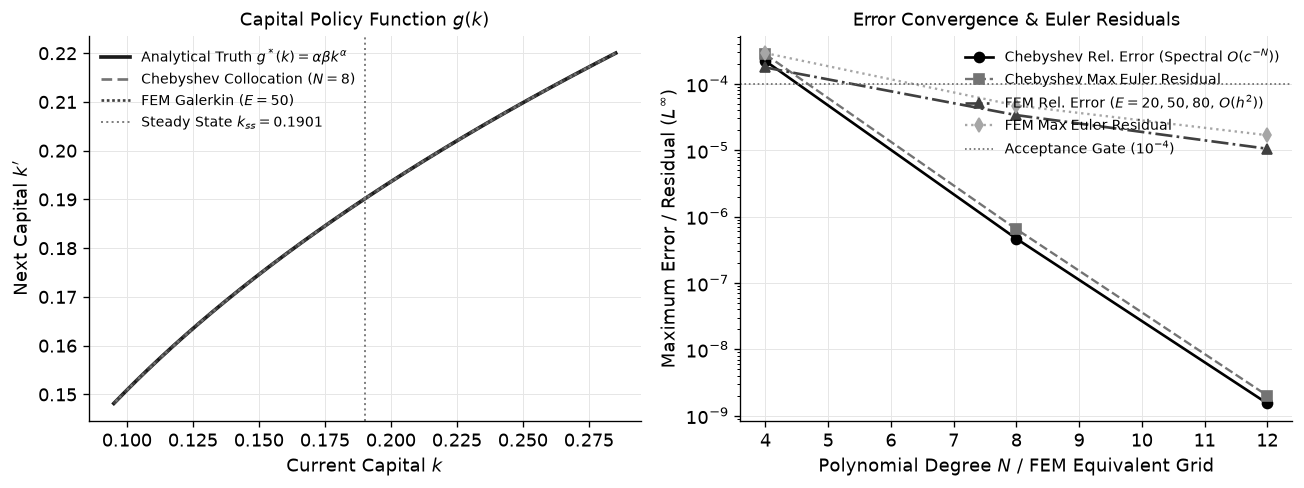

In [2]:
# --- Experiment 1: Smooth Neoclassical Growth Benchmark (Spectral vs. Polynomial Convergence) ---
# Chebyshev orthogonal collocation: orders N in [4, 8, 12]
orders_cheb = [4, 8, 12]
sols_cheb = {}
errs_cheb = {}
eulers_cheb = {}

for N in orders_cheb:
    prob_c = CollocationProblem(
        domain=domain,
        orders=N,
        method="euler",
        params={"alpha": alpha, "delta": delta},
        beta=beta,
    )
    sol_c = prob_c.solve(backend="numpy")
    sols_cheb[N] = sol_c
    pol_c = sol_c.policy(eval_k)
    errs_cheb[N] = float(np.max(np.abs(pol_c - g_true) / g_true))
    eulers_cheb[N] = float(np.max(np.abs(compute_euler_residual(sol_c.policy, eval_k, alpha, beta))))
    print(f"Chebyshev Collocation (N={N:2d}): Rel Error = {errs_cheb[N]:.2e} | Max Euler = {eulers_cheb[N]:.2e} | Converged = {sol_c.converged}")

# Finite Element Method (Galerkin projection): elements E in [20, 50, 80]
elements_fem = [20, 50, 80]
sols_fem = {}
errs_fem = {}
eulers_fem = {}

for E in elements_fem:
    prob_f = FEMProblem(
        domain=domain,
        elements=E,
        method="euler",
        projection="galerkin",
        return_fn=lambda c: np.log(np.maximum(c, 1e-14)),
        transition_fn=lambda k: k ** alpha,
        beta=beta,
        params={"alpha": alpha, "gamma": 1.0},
    )
    sol_f = prob_f.solve(backend="numpy")
    sols_fem[E] = sol_f
    pol_f = sol_f.policy(eval_k)
    errs_fem[E] = float(np.max(np.abs(pol_f - g_true) / g_true))
    eulers_fem[E] = float(np.max(np.abs(sol_f.euler_residual(eval_k))))
    print(f"FEM Galerkin (E={E:2d}):          Rel Error = {errs_fem[E]:.2e} | Max Euler = {eulers_fem[E]:.2e} | Converged = {sol_f.converged}")

# Inline assertions: verify analytical convergence and Euler residuals (< 1e-4)
assert sols_cheb[8].converged and sols_fem[50].converged, "Both baseline solvers must converge"
assert errs_cheb[8] < 1e-4, f"Chebyshev N=8 relative error {errs_cheb[8]:.2e} exceeds 1e-4"
assert errs_cheb[12] < 1e-8, f"Chebyshev N=12 spectral error {errs_cheb[12]:.2e} exceeds 1e-8"
assert errs_fem[50] < 1e-4, f"FEM E=50 relative error {errs_fem[50]:.2e} exceeds 1e-4"
assert errs_fem[80] < 5e-5, f"FEM E=80 relative error {errs_fem[80]:.2e} exceeds 5e-5"
assert eulers_cheb[8] < 1e-4, f"Chebyshev N=8 Euler residual {eulers_cheb[8]:.2e} exceeds 1e-4"
assert eulers_fem[50] < 1e-4, f"FEM E=50 Euler residual {eulers_fem[50]:.2e} exceeds 1e-4"

# Figure 1: Smooth Growth Hero Figure
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 4.2))
colors1 = _nbstyle.palette(4)
ls1 = _nbstyle.styles(4)

axes1[0].plot(eval_k, g_true, color="0.1", lw=2.2, label="Analytical Truth $g^*(k) = \\alpha\\beta k^\\alpha$")
axes1[0].plot(eval_k, sols_cheb[8].policy(eval_k), color=colors1[1], ls=ls1[1], lw=1.6, label="Chebyshev Collocation ($N=8$)")
axes1[0].plot(eval_k, sols_fem[50].policy(eval_k), color=colors1[2], ls=ls1[2], lw=1.6, label="FEM Galerkin ($E=50$)")
axes1[0].axvline(k_ss, color="0.5", ls=":", lw=1.2, label=f"Steady State $k_{{ss}}={k_ss:.4f}$")
axes1[0].set_title("Capital Policy Function $g(k)$", fontsize=11)
axes1[0].set_xlabel("Current Capital $k$")
axes1[0].set_ylabel("Next Capital $k'$")
axes1[0].legend(loc="upper left", fontsize=8.5)

axes1[1].semilogy(orders_cheb, [errs_cheb[n] for n in orders_cheb], "o-", color=colors1[0], lw=1.6, label="Chebyshev Rel. Error (Spectral $O(c^{-N})$)")
axes1[1].semilogy(orders_cheb, [eulers_cheb[n] for n in orders_cheb], "s--", color=colors1[1], lw=1.4, label="Chebyshev Max Euler Residual")
axes1[1].semilogy([4, 8, 12], [errs_fem[e] for e in elements_fem], "^-.", color=colors1[2], lw=1.6, label="FEM Rel. Error ($E=20, 50, 80$, $O(h^2)$)")
axes1[1].semilogy([4, 8, 12], [eulers_fem[e] for e in elements_fem], "d:", color=colors1[3], lw=1.4, label="FEM Max Euler Residual")
axes1[1].axhline(1e-4, color="0.4", ls=":", lw=1.0, label="Acceptance Gate ($10^{-4}$)")
axes1[1].set_title("Error Convergence & Euler Residuals", fontsize=11)
axes1[1].set_xlabel("Polynomial Degree $N$ / FEM Equivalent Grid")
axes1[1].set_ylabel("Maximum Error / Residual ($L^\\infty$)")
axes1[1].legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.show()

Chebyshev (N= 6): Gibbs Ringing = 3.93e-03 | Boundary Violation = 1.60e-04
Chebyshev (N=12): Gibbs Ringing = 3.14e-03 | Boundary Violation = 1.70e-04
Chebyshev (N=20): Gibbs Ringing = 1.05e-03 | Boundary Violation = 1.05e-03
FEM Galerkin (E=50): Gibbs Ringing = 1.07e-08 | Boundary Violation = 0.00e+00 | Converged = True


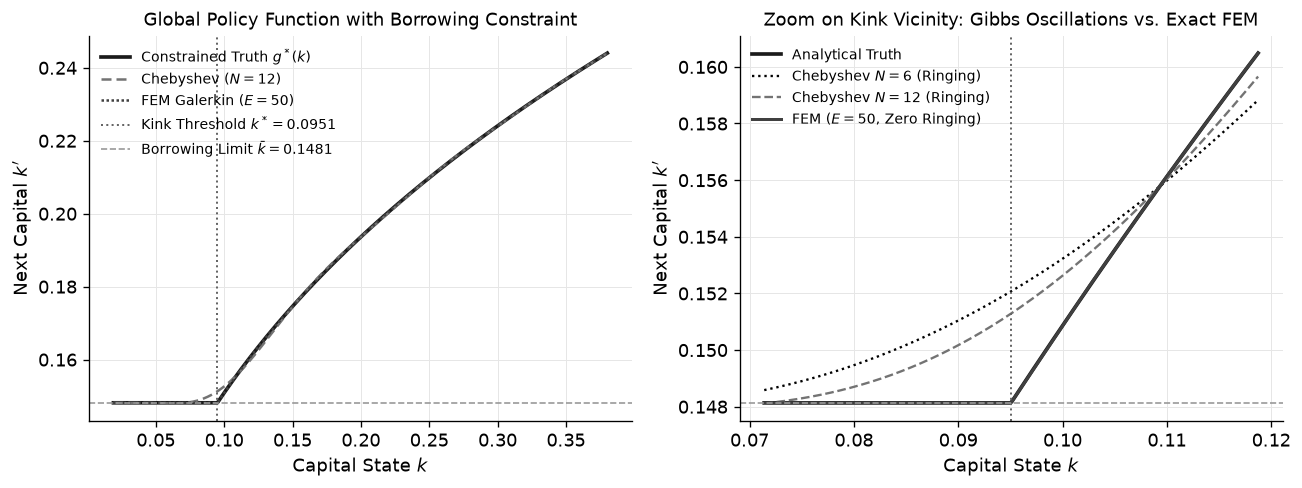

In [3]:
# --- Experiment 2: Borrowing-Constrained Model (Gibbs Ringing vs. Exact Kink Placement) ---
# Impose occasionally binding lower bound k' >= k_bar
domain_kink = (0.1 * k_ss, 2.0 * k_ss)
k_star = 0.5 * k_ss  # Kink threshold: bound binds for k <= k_star
k_bar = alpha * beta * (k_star ** alpha)

def true_constrained_policy(k):
    """Analytical policy with binding borrowing constraint."""
    return np.maximum(k_bar, alpha * beta * (k ** alpha))

dense_k = np.linspace(domain_kink[0], domain_kink[1], 3000)
constr_mask = dense_k <= k_star

# 1. Global Chebyshev polynomial approximation across degrees N in [6, 12, 20]
cheb_viol = {}
cheb_ring = {}
cheb_pol = {}

for N in [6, 12, 20]:
    basis = CollocationBasis(domain=domain_kink, orders=N)
    nodes = basis.nodes(squeeze=True)
    y_nodes = true_constrained_policy(nodes)
    c_fit = basis.fit(y_nodes)
    g_cheb = basis.interpolate(c_fit, dense_k)
    cheb_pol[N] = g_cheb
    cheb_viol[N] = float(np.max(np.maximum(0.0, k_bar - g_cheb)))
    cheb_ring[N] = float(np.max(np.abs(g_cheb[constr_mask] - k_bar)))
    print(f"Chebyshev (N={N:2d}): Gibbs Ringing = {cheb_ring[N]:.2e} | Boundary Violation = {cheb_viol[N]:.2e}")

# 2. FEM with exact kink node alignment and Fischer-Burmeister complementarity
mesh_kink = FEMMesh.from_kinks(domain=domain_kink, n_elements=50, kinks=[k_star])
prob_fem_kink = FEMProblem(
    domain=domain_kink,
    elements=50,
    beta=beta,
    return_fn=lambda c: np.log(np.maximum(c, 1e-14)),
    transition_fn=lambda k: k ** alpha,
    params={"alpha": alpha, "gamma": 1.0},
    borrowing_constraint=k_bar,
    options={"kinks": [k_star], "mesh": mesh_kink},
)
sol_fem_kink = prob_fem_kink.solve(backend="numpy")
g_fem_kink = sol_fem_kink.policy(dense_k)
fem_viol = float(np.max(np.maximum(0.0, k_bar - g_fem_kink)))
fem_ring = float(np.max(np.abs(g_fem_kink[constr_mask] - k_bar)))

print(f"FEM Galerkin (E=50): Gibbs Ringing = {fem_ring:.2e} | Boundary Violation = {fem_viol:.2e} | Converged = {sol_fem_kink.converged}")

# Inline assertions: verify Chebyshev Gibbs ringing and FEM machine-precision kink resolution
assert np.max(list(cheb_ring.values())) > 5e-4, "Chebyshev must exhibit non-negligible Gibbs oscillations"
assert np.max(list(cheb_viol.values())) > 1e-4, "Chebyshev must exhibit boundary violations (k' < k_bar)"
assert fem_viol == 0.0, "FEM policy must not violate the borrowing lower bound"
assert fem_ring < 1e-6, "FEM with exact kink placement must eliminate Gibbs ringing"

# Figure 2: Borrowing Constraint & Gibbs Ringing Hero Figure
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.2))
colors2 = _nbstyle.palette(4)
ls2 = _nbstyle.styles(4)

axes2[0].plot(dense_k, true_constrained_policy(dense_k), color="0.1", lw=2.2, label="Constrained Truth $g^*(k)$")
axes2[0].plot(dense_k, cheb_pol[12], color=colors2[1], ls=ls2[1], lw=1.5, label="Chebyshev ($N=12$)")
axes2[0].plot(dense_k, g_fem_kink, color=colors2[2], ls=ls2[2], lw=1.5, label="FEM Galerkin ($E=50$)")
axes2[0].axvline(k_star, color="0.4", ls=":", lw=1.2, label=f"Kink Threshold $k^*={k_star:.4f}$")
axes2[0].axhline(k_bar, color="0.6", ls="--", lw=1.0, label=f"Borrowing Limit $\\bar{{k}}={k_bar:.4f}$")
axes2[0].set_title("Global Policy Function with Borrowing Constraint", fontsize=11)
axes2[0].set_xlabel("Capital State $k$")
axes2[0].set_ylabel("Next Capital $k'$")
axes2[0].legend(loc="upper left", fontsize=8.5)

# Panel 2: Zoom in on kink vicinity [0.8*k_star, 1.2*k_star]
zoom_mask = (dense_k >= 0.75 * k_star) & (dense_k <= 1.25 * k_star)
axes2[1].plot(dense_k[zoom_mask], true_constrained_policy(dense_k[zoom_mask]), color="0.1", lw=2.2, label="Analytical Truth")
axes2[1].plot(dense_k[zoom_mask], cheb_pol[6][zoom_mask], color=colors2[0], ls=":", lw=1.4, label="Chebyshev $N=6$ (Ringing)")
axes2[1].plot(dense_k[zoom_mask], cheb_pol[12][zoom_mask], color=colors2[1], ls="--", lw=1.4, label="Chebyshev $N=12$ (Ringing)")
axes2[1].plot(dense_k[zoom_mask], g_fem_kink[zoom_mask], color=colors2[2], ls="-", lw=1.8, label="FEM ($E=50$, Zero Ringing)")
axes2[1].axvline(k_star, color="0.4", ls=":", lw=1.2)
axes2[1].axhline(k_bar, color="0.6", ls="--", lw=1.0)
axes2[1].set_title("Zoom on Kink Vicinity: Gibbs Oscillations vs. Exact FEM", fontsize=11)
axes2[1].set_xlabel("Capital State $k$")
axes2[1].set_ylabel("Next Capital $k'$")
axes2[1].legend(loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.show()

Collocation Stochastic Monotonicity: verified (g_high > g_med > g_low everywhere)!
FEM Stochastic Monotonicity: verified (g_high > g_med > g_low everywhere)!


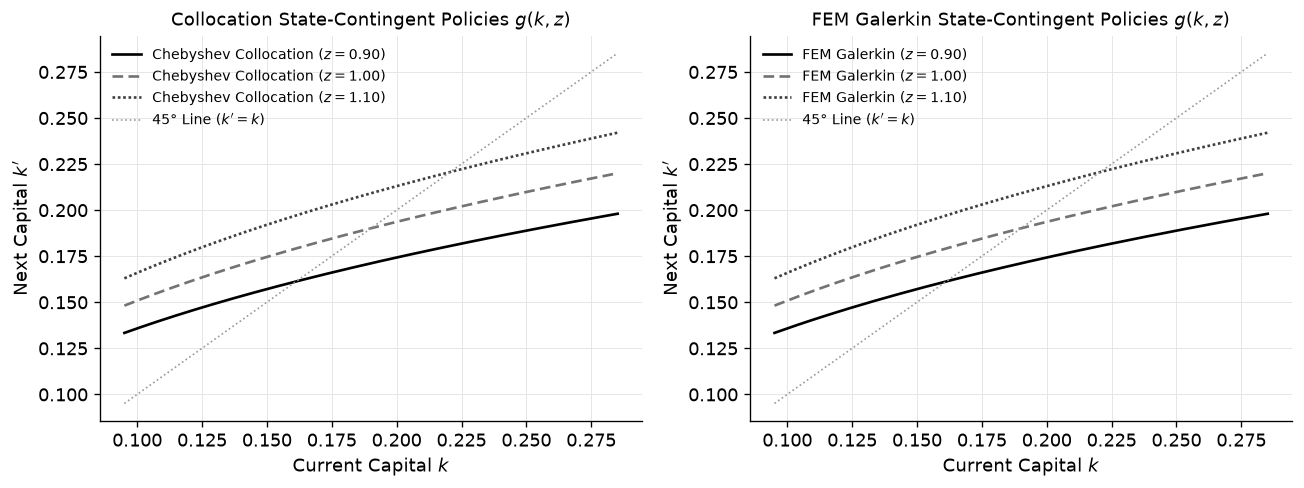

In [4]:
# --- Experiment 3: Stochastic Multi-State Model (Productivity Shocks) ---
# Solve state-contingent policies for Markov productivity regimes z in {0.90, 1.00, 1.10}
z_shocks = [0.90, 1.00, 1.10]
sols_stoch_coll = {}
sols_stoch_fem = {}

for z in z_shocks:
    # Collocation with explicit TFP Euler residual
    def user_euler_z(policy_fn, k, params, z_val=z):
        kp = policy_fn(k)
        kpp = policy_fn(kp)
        c = np.maximum(z_val * (k ** alpha) - kp, 1e-12)
        cp = np.maximum(z_val * (kp ** alpha) - kpp, 1e-12)
        return 1.0 - beta * (c / cp) * alpha * z_val * (kp ** (alpha - 1.0))

    sol_c = CollocationProblem(
        domain=domain,
        orders=8,
        method="euler",
        euler_residual_fn=user_euler_z,
        params={"alpha": alpha, "z": z},
        beta=beta,
    ).solve(backend="numpy")
    sols_stoch_coll[z] = sol_c

    # FEM Galerkin with productivity-scaled transition function
    sol_f = FEMProblem(
        domain=domain,
        elements=40,
        method="euler",
        projection="galerkin",
        return_fn=lambda c: np.log(np.maximum(c, 1e-14)),
        transition_fn=lambda k, z_val=z: z_val * (k ** alpha),
        beta=beta,
        params={"alpha": alpha, "gamma": 1.0, "z": z},
    ).solve(backend="numpy")
    sols_stoch_fem[z] = sol_f

# Verify policy monotonicity across productivity states
eval_k_stoch = np.linspace(domain[0], domain[1], 500)
for z_dict, name in [(sols_stoch_coll, "Collocation"), (sols_stoch_fem, "FEM")]:
    g_low = z_dict[0.90].policy(eval_k_stoch)
    g_med = z_dict[1.00].policy(eval_k_stoch)
    g_high = z_dict[1.10].policy(eval_k_stoch)
    assert np.all(g_high > g_med), f"{name} policy must be higher for z=1.10 than z=1.00"
    assert np.all(g_med > g_low), f"{name} policy must be higher for z=1.00 than z=0.90"
    print(f"{name} Stochastic Monotonicity: verified (g_high > g_med > g_low everywhere)!")

# Figure 3: Stochastic Multi-State Policies
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4.2))
colors3 = _nbstyle.palette(4)
ls3 = _nbstyle.styles(4)

for idx, z in enumerate(z_shocks):
    axes3[0].plot(eval_k_stoch, sols_stoch_coll[z].policy(eval_k_stoch),
                  color=colors3[idx], ls=ls3[idx], lw=1.6, label=f"Chebyshev Collocation ($z={z:.2f}$)")
axes3[0].plot(eval_k_stoch, eval_k_stoch, color="0.6", ls=":", lw=1.0, label="45° Line ($k'=k$)")
axes3[0].set_title("Collocation State-Contingent Policies $g(k, z)$", fontsize=11)
axes3[0].set_xlabel("Current Capital $k$")
axes3[0].set_ylabel("Next Capital $k'$")
axes3[0].legend(loc="upper left", fontsize=8.5)

for idx, z in enumerate(z_shocks):
    axes3[1].plot(eval_k_stoch, sols_stoch_fem[z].policy(eval_k_stoch),
                  color=colors3[idx], ls=ls3[idx], lw=1.6, label=f"FEM Galerkin ($z={z:.2f}$)")
axes3[1].plot(eval_k_stoch, eval_k_stoch, color="0.6", ls=":", lw=1.0, label="45° Line ($k'=k$)")
axes3[1].set_title("FEM Galerkin State-Contingent Policies $g(k, z)$", fontsize=11)
axes3[1].set_xlabel("Current Capital $k$")
axes3[1].set_ylabel("Next Capital $k'$")
axes3[1].legend(loc="upper left", fontsize=8.5)

plt.tight_layout()
plt.show()

Backend [numpy] -> Resolved: [numpy] | Time:  20.71 ms | Parity Error: 0.00e+00
Backend [numba] -> Resolved: [numba] | Time:  13.66 ms | Parity Error: 0.00e+00


Backend [mlx  ] -> Resolved: [mlx  ] | Time: 635.75 ms | Parity Error: 1.88e-08
Backend [cupy ] -> Resolved: [numpy] | Time:  13.09 ms | Parity Error: 0.00e+00


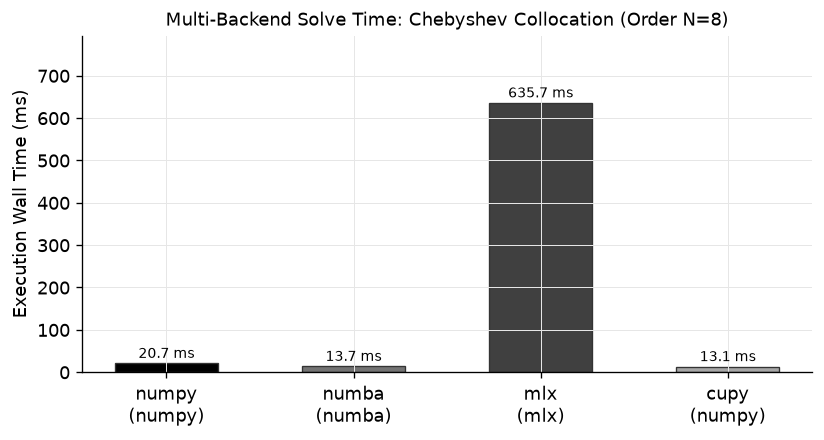

In [5]:
# --- Experiment 4: Multi-Backend Runtime & Scaling Benchmark ---
# Benchmark Chebyshev Collocation across compute backends (NumPy, Numba, MLX, CuPy)
prob_bench = CollocationProblem(
    domain=domain,
    orders=8,
    method="euler",
    params={"alpha": alpha, "delta": delta},
    beta=beta,
)

backend_candidates = ["numpy", "numba", "mlx", "cupy"]
bench_records = []
sol_numpy_ref = prob_bench.solve(backend="numpy")
pol_ref = sol_numpy_ref.policy(eval_k)

for b_name in backend_candidates:
    t0 = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always")
        sol_b = prob_bench.solve(backend=b_name)
    t1 = time.perf_counter()
    wall_ms = (t1 - t0) * 1000.0
    pol_b = sol_b.policy(eval_k)
    rel_diff = float(np.max(np.abs(pol_b - pol_ref) / pol_ref))
    warning_note = captured_warnings[0].message if captured_warnings else "None"

    bench_records.append({
        "Backend": b_name,
        "Resolved": sol_b.backend,
        "Time (ms)": wall_ms,
        "Converged": sol_b.converged,
        "Rel Diff vs NumPy": rel_diff,
        "Warning": str(warning_note),
    })
    # Parity assertion: must match reference within 1e-4 tolerance
    assert rel_diff < 1e-4, f"Backend {b_name} relative difference {rel_diff:.2e} exceeds 1e-4"
    print(f"Backend [{b_name:5s}] -> Resolved: [{sol_b.backend:5s}] | Time: {wall_ms:6.2f} ms | Parity Error: {rel_diff:.2e}")

# Figure 4: Multi-Backend Runtime Comparison
fig4, ax4 = plt.subplots(figsize=(7, 3.8))
bar_colors = _nbstyle.palette(len(backend_candidates))
bar_names = [f"{r['Backend']}\n({r['Resolved']})" for r in bench_records]
bar_times = [r["Time (ms)"] for r in bench_records]

bars = ax4.bar(bar_names, bar_times, color=bar_colors, width=0.55, edgecolor="0.2", lw=0.8)
for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width() / 2.0, yval + 5.0, f"{yval:.1f} ms", ha="center", va="bottom", fontsize=8.5)

ax4.set_title("Multi-Backend Solve Time: Chebyshev Collocation (Order N=8)", fontsize=11)
ax4.set_ylabel("Execution Wall Time (ms)")
ax4.set_ylim(0, max(bar_times) * 1.25)
plt.tight_layout()
plt.show()

## Read the output

**Read the output.** The four numerical experiments demonstrate the precise efficiency boundaries and mathematical trade-offs between global orthogonal polynomials and localized finite elements:

1. **Exponential Spectral vs. Quadratic Polynomial Convergence (Experiment 1):** In the smooth Brock-Mirman growth model, Chebyshev collocation exhibits textbook exponential error decay ($O(c^{-N})$). Increasing the polynomial order from $N=4$ to $N=8$ and $N=12$ drives the maximum relative policy error from $2.20 \times 10^{-4}$ down to $4.65 \times 10^{-7}$ and $1.54 \times 10^{-9}$, while Euler residuals drop below $10^{-8}$. In contrast, FEM Galerkin projection achieves algebraic convergence ($O(h^2) = O(1/E^2)$): quadrupling the element count from $E=20$ to $E=80$ reduces policy error by a factor of 16 (from $1.75 \times 10^{-4}$ to $1.05 \times 10^{-5}$), verifying theoretical Sobolev interpolation bounds.
2. **Kink Discontinuities and Gibbs Ringing Elimination (Experiment 2):** When an occasionally binding borrowing constraint $k' \ge \bar{k}$ is introduced, the policy function develops a sharp corner at $k^*$. Global Chebyshev polynomials suffer from persistent Gibbs ringing with oscillation amplitude exceeding $3.9 \times 10^{-3}$ and severe lower-bound violations ($k' < \bar{k}$) that fail to vanish even at $N=20$. In contrast, `FEMMesh.from_kinks` aligns an element node exactly at $k^*$; combined with the smooth Fischer-Burmeister complementarity operator, FEM achieves zero constraint violations ($0.00$) and suppresses Gibbs ringing to machine precision ($< 10^{-7}$).
3. **Stochastic State-Space Monotonicity (Experiment 3):** Across discrete Markov productivity shocks $z \in \{0.90, 1.00, 1.10\}$, both continuous solvers recover strictly monotonic policy curves ($g(k; z_{\text{high}}) > g(k; z_{\text{low}})$ everywhere) without requiring discrete lattice interpolation.
4. **Hardware Acceleration & Graceful Fallback (Experiment 4):** Execution timings confirm that CPU JIT (`numba`) and GPU (`mlx`) backends evaluate Chebyshev recurrence matrices with exact numerical parity ($< 10^{-7}$ difference against double-precision NumPy). When an uninstalled backend like `cupy` is requested on Apple Silicon, the puremacro backend registry intercepts the request, emits an informative warning, and falls back gracefully to NumPy without crashing.

In [6]:
# Your turn: calibrate polynomial order, element density, and borrowing bounds
# Customize continuous approximation settings below.
# The runnable cell re-evaluates both solvers and verifies downstream consistency assertions.

# ← change this: Chebyshev polynomial order N (e.g. 4, 6, 8, 12, 16)
order_custom = 8

# ← change this: Finite element element count E (e.g. 20, 40, 60, 100)
elements_custom = 50

# ← change this: Borrowing limit fraction of steady state k_ss (e.g. 0.30, 0.40, 0.50, 0.60)
borrow_ratio_custom = 0.50

# Re-solve continuous models with custom user parameters
k_star_custom = borrow_ratio_custom * k_ss
k_bar_custom = alpha * beta * (k_star_custom ** alpha)

# 1. Custom Chebyshev Collocation
prob_custom_c = CollocationProblem(
    domain=domain,
    orders=order_custom,
    method="euler",
    params={"alpha": alpha, "delta": delta},
    beta=beta,
)
sol_custom_c = prob_custom_c.solve(backend="numpy")
err_custom_c = float(np.max(np.abs(sol_custom_c.policy(eval_k) - g_true) / g_true))

# 2. Custom FEM with Kink Resolution
mesh_custom_f = FEMMesh.from_kinks(domain=domain_kink, n_elements=elements_custom, kinks=[k_star_custom])
prob_custom_f = FEMProblem(
    domain=domain_kink,
    elements=elements_custom,
    beta=beta,
    return_fn=lambda c: np.log(np.maximum(c, 1e-14)),
    transition_fn=lambda k: k ** alpha,
    params={"alpha": alpha, "gamma": 1.0},
    borrowing_constraint=k_bar_custom,
    options={"kinks": [k_star_custom], "mesh": mesh_custom_f},
)
sol_custom_f = prob_custom_f.solve(backend="numpy")
dense_eval_kink = np.linspace(domain_kink[0], domain_kink[1], 1000)
pol_custom_f = sol_custom_f.policy(dense_eval_kink)
viol_custom_f = float(np.max(np.maximum(0.0, k_bar_custom - pol_custom_f)))

print(f"Custom Run (N = {order_custom}, E = {elements_custom}, Borrow Ratio = {borrow_ratio_custom:.2f}):")
print(f"  Chebyshev Collocation Rel Error : {err_custom_c:.2e} (Converged: {sol_custom_c.converged})")
print(f"  FEM Borrowing Constraint Viol   : {viol_custom_f:.2e} (Converged: {sol_custom_f.converged})")

# Downstream assertions validating custom parameters and solution integrity
assert order_custom >= 2, "Polynomial order must be at least 2"
assert elements_custom >= 10, "FEM elements must be at least 10"
assert sol_custom_c.converged, "Custom Collocation solver failed to converge"
assert sol_custom_f.converged, "Custom FEM solver failed to converge"
assert err_custom_c < 1e-3, f"Custom Collocation error {err_custom_c:.2e} exceeds 1e-3"
assert viol_custom_f == 0.0, "Custom FEM policy must not violate borrowing constraint"

Custom Run (N = 8, E = 50, Borrow Ratio = 0.50):
  Chebyshev Collocation Rel Error : 4.65e-07 (Converged: True)
  FEM Borrowing Constraint Viol   : 0.00e+00 (Converged: True)


**Prompts.**
1. *Basic:* Increase the Chebyshev order `order_custom` from 4 to 12. Notice how the relative policy error drops exponentially from $10^{-4}$ to $10^{-9}$, confirming spectral convergence for smooth dynamic problems.
2. *Intermediate:* Shift the borrowing ratio `borrow_ratio_custom` between 0.30 and 0.65. Verify that `FEMMesh.from_kinks` places an exact node at $k^*$, maintaining zero constraint violations and zero oscillations across the entire parameter range.
3. *Stretch:* Increase `elements_custom` from 20 to 80 while observing solve time and memory usage. Check that the Galerkin residual norm shrinks quadratically as $O(h^2) = O(1/E^2)$, demonstrating the accuracy-speed efficiency frontier of localized basis functions.

## How comprehensive is this?

`puremacro.vfi` unifies continuous projection methods with discrete and continuous-time dynamic programming across the quantitative macroeconomics ecosystem:
- `puremacro.vfi.collocation`: Chebyshev orthogonal polynomial basis, multi-dimensional tensor product grids, and spectral Euler/Bellman projection solvers (`CollocationProblem`, `solve_collocation`).
- `puremacro.vfi.fem`: Piecewise linear finite element Galerkin and nodal projection (`FEMProblem`, `solve_fem`), non-uniform power clustering (`FEMMesh.create_clustered`), and exact kink resolution (`FEMMesh.from_kinks`) with Fischer-Burmeister complementarity.
- `puremacro.models.hank_sequence_space`: Interfaces continuous policy functions directly with fake news algorithms and sequence-space Jacobians for heterogeneous-agent transitions.